# 16 매매 자동화

## 16.1 자금 관리

"전체 가용 자금 중에서 어느 정도의 자금을 어떤 알고리즘 트레이딩 전략에 할당하는가?"

- **장기 자산의 최대화**

- 에드워드 소프(Edward Thorpe)의 투자를 위한 켈리 기준(Kelly criterion)

### 16.1.1 이항 분포에서 켈리 기준

도박사가 동전 던지기 게임을 한다고 가정.

- 앞면이 나올 확률 $p$: $\dfrac{1}{2} < p < 1$

- 뒷면이 나올 확률: $q = 1 - p < \dfrac{1}{2}$

도박사는 $b > 0$이라는 금액을 걸 수 있음. 

도박사가 이기면 같은 금액을 받게 되고, 지면 이 금액을 모두 잃음.

- 한번 던졌을 때 도박사가 받는 돈의 기댓값 $B$: $E[B] = p \cdot b - q \cdot b = (p - q) \cdot b > 0$

금융 시장에서의 매매는 반복 시행. 

- 처음 가진 돈: $c_0$, $i$번째 날에 베팅하는 돈: $b_i$

- $n$번 반복한 도박의 기댓값: $E[B^n] = c_0 + \sum\limits^{n}_{i=1} (p - q) \cdot b_i$

고전 경제학 이론에서 위험 중립적이고 기대효용성을 최대화하려는 도박사는 이 수식값을 최대화하고 싶을 것.

남아있는 돈을 모두 도박에 걸면 갑작스러운 파산에 이를 수 있고, 아무것도 걸지 않으면 돈을 얻을 수도 없음.

켈리 기준 Kelly criterion: 남아있는 돈 중에서 걸어야 할 돈의 최적 비율 $f^*$를 찾는 것.

- $n = h + t$라 가정. $h$는 동전을 $n$번 던져서 앞면이 나온 횟수, $t$는 뒷면이 나온 횟수.

- $n$번 던졌을 때 남은 돈: $c_n = c_0 \cdot (1 + f)^h \cdot (1 - f)^t$

이 상황에서 장기적으로 자산을 최대화하려면 한 번의 도박 당 기하평균 수익률을 최대화해야함.

- $\begin{aligned} 
r^g &= log \left( \dfrac{c_n}{c_0} \right)^{1/n} \\ 
&= log \left( \dfrac{c_0 \cdot (1 + f)^h \cdot (1 - f)^t}{c_0} \right)^{1/n} \\ 
&= log \left( (1 + f)^h \cdot (1 - f)^t \right)^{1/n} \\
&= \dfrac{h}{n} log(1 + f) + \dfrac{t}{n} log(1 - f)
\end{aligned}$

이 문제는 기대 평균을 최대화하는 최적 $f$를 고르는 것과 같음. 

$E[h] = n \cdot p$와 $E[t] = n \cdot q$를 이용.

- $\begin{aligned}
E[r^g] &= E \left[ \dfrac{h}{n} log(1 + f) + \dfrac{t}{n} log(1 - f) \right] \\
&= E[p \cdot log(1 + f) + q \cdot log(1 - f)] \\
&= p \cdot log(1 + f) + q \cdot log(1 - f) \\
&\equiv G(f)
\end{aligned}$

1차 미분 조건에 따라 위 식을 최대화하는 최적 비율 $f^*$를 찾기.

- $\begin{aligned} 
G'(f) &= \dfrac{p}{1 + f} - \dfrac{q}{1 - f} \\
&= \dfrac{p - pf - q - qf}{(1 + f)(1 - f)} \\
&= \dfrac{p - q - f}{(1 + f)(1 - f)}
\end{aligned}$

1차 미분 조건에서 최적 비율: 

- $G'(f) = 0 \Rightarrow f^* = p - q$

한 번의 도박마다 $f^* = p - q$ 비율만큼의 돈을 거는 것이 최적.

In [1]:
import math
import time
import numpy as np
import pandas as pd
import datetime as dt
import cufflinks as cf
import matplotlib.pyplot as plt

In [2]:
np.random.seed(1000)
%matplotlib inline

동전을 100번 던지는 행위를 50회 반복

In [3]:
p = 0.55 # 앞면이 나올 확률

In [4]:
f = p - (1 - p) # 켈리 기준에 따른 최적 비율

In [5]:
f

0.10000000000000009

In [6]:
I = 50 # 반복 횟수

In [7]:
n = 100 # 동전을 던지는 횟수

In [8]:
def run_simulation(f):
    c = np.zeros((n, I)) # 시뮬레이션 결과를 저장할 ndarray
    c[0] = 100 # 시작 자금을 100으로 고정
    for i in range(I): # 반복을 위한 외부 반복문
        for t in range(1, n): # 동전 던지기를 위한 내부 반복문
            o = np.random.binomial(1, p) # 동전 던지기 시뮬레이션
            if o > 0: # 만약 1(앞면)이 나오면
                c[t, i] = c[t - 1, i] * (1 + f) # 돈을 받는다.
            else: # 만약 0(뒷면)이 나오면
                c[t, i] = c[t - 1, i] * (1 - f) # 돈을 잃는다.
    return c

In [9]:
c_1 = run_simulation(f)

In [10]:
c_1.round(2)

array([[100.  , 100.  , 100.  , ..., 100.  , 100.  , 100.  ],
       [ 90.  , 110.  ,  90.  , ..., 110.  ,  90.  , 110.  ],
       [ 99.  , 121.  ,  99.  , ..., 121.  ,  81.  , 121.  ],
       ...,
       [226.35, 338.13, 413.27, ..., 123.97, 123.97, 123.97],
       [248.99, 371.94, 454.6 , ..., 136.37, 136.37, 136.37],
       [273.89, 409.14, 409.14, ..., 122.73, 150.01, 122.73]],
      shape=(100, 50))

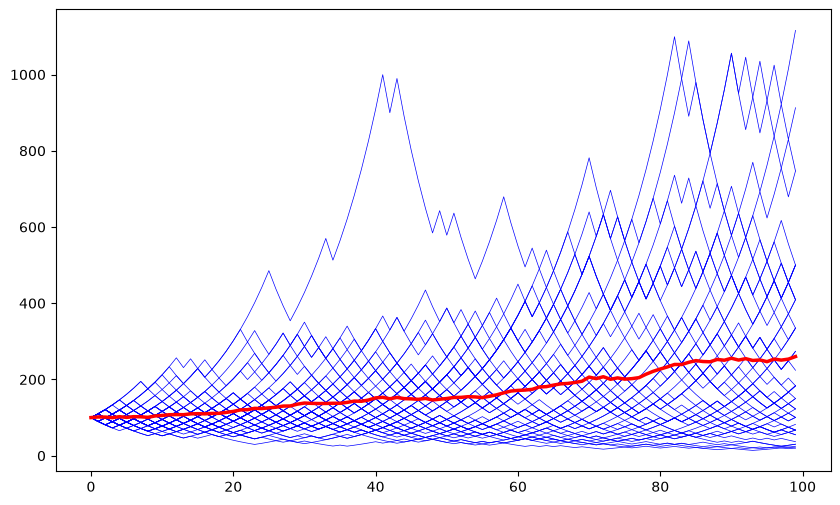

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(c_1, 'b', lw=0.5)
plt.plot(c_1.mean(axis=1), 'r', lw=2.5)

여러 가지 $f$값에 대해 시뮬레이션을 반복. 

비율이 너무 낮으면 평균 수익률이 낮아짐.

비율이 높아지면 최종 자산이 증가할 수도 있지만$(f = 0.25)$ 오히려 더 감소할 수도 있음$(f = 0.5)$.

두 경우 모두 비율 $f$가 높아서 변동성이 크게 증가.

In [12]:
c_2 = run_simulation(0.05) # f = 0.05인 경우의 시뮬레이션

In [13]:
c_3 = run_simulation(0.25) # f = 0.25인 경우의 시뮬레이션

In [14]:
c_4 = run_simulation(0.5) # f = 0.5인 경우의 시뮬레이션

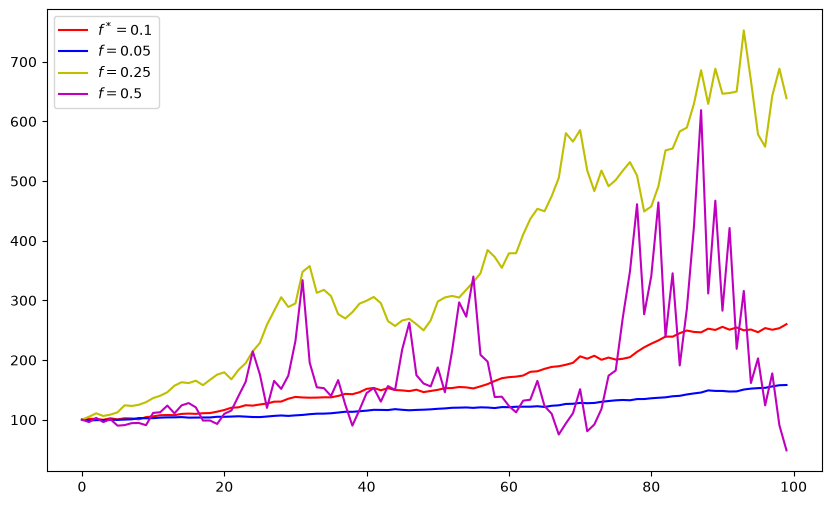

In [15]:
plt.figure(figsize=(10, 6))
plt.plot(c_1.mean(axis=1), 'r', label='$f^*=0.1$')
plt.plot(c_2.mean(axis=1), 'b', label='$f=0.05$')
plt.plot(c_3.mean(axis=1), 'y', label='$f=0.25$')
plt.plot(c_4.mean(axis=1), 'm', label='$f=0.5$')
plt.legend(loc=0)

### 16.1.2 주식과 지수에 대한 켈리 기준

이항 분포와 마찬가지로 1년 후에 두 가지 값만 있다고 가정.

주식 기대수익률과 변동성 모형을 반영.

- $P(r^S = \mu + \sigma) = P(r^S = \mu - \sigma) = \dfrac{1}{2}$

$E \left[ r^S \right] = \mu > 0$은 1년 후의 기대 수익률, $\sigma > 0$는 수익률의 표준편차(변동성)

1년을 기준으로 하면 자산은 다음과 같이 증가.

- $c(f) = c_0 \cdot (1 + (1 - f) \cdot r + f \cdot r^S)$

$r$은 주식에 투자하지 않은 현금에 대한 고정 단기 이자율. 

기하 수익률 평균을 최대화하는 것은 다음 항을 최대화하는 것.

- $G(f) = E \left[ log \dfrac{c(f)}{c_0} \right]$

1년에 $n$개의 매매일이 있고, 각각의 $i$번째 날에 대해 다음 식이 성립한다고 가정. 

- $P \left( r_i^S = \dfrac{\mu}{n} + \dfrac{\sigma}{\sqrt{n}} \right) = P \left( r_i^S = \dfrac{\mu}{n} - \dfrac{\sigma}{\sqrt{n}} \right) = \dfrac{1}{2}$

변동성은 매매일수의 제곱근에 비례.

이 가정 하에서 1년 후의 자산은 다음과 같아짐.

- $c_n(f) = c_0 \cdot \prod_{i=1}^{n} \left( 1 + (1 - f) \cdot \dfrac{r}{n} + f \cdot r_i^S \right)$

주식 투자에서 장기 자산을 최대화

- $\begin{aligned}
G_n(f) &= E \left[ log \dfrac{c_n(f)}{c_0} \right] \\
&= E \left[ \sum\limits_{i=1}^{n} log \left( 1 + (1 - f) \cdot \dfrac{r}{n} + f \cdot r_i^S \right) \right] \\
&= \dfrac{1}{2} \sum\limits_{i=1}^{n} log \left( 1 + (1 - f) \cdot \dfrac{r}{n} + f \cdot \left( \dfrac{\mu}{n} + \dfrac{\sigma}{\sqrt{n}} \right) \right) + log \left( 1 + (1 - f) \cdot \dfrac{r}{n} + f \cdot \left( \dfrac{\mu}{n} - \dfrac{\sigma}{\sqrt{n}} \right) \right) \\
&= \dfrac{1}{2} \sum\limits_{i=1}^{n} log \left( \left( 1 + (1 - f) \cdot \dfrac{r}{n} + f \cdot \dfrac{\mu}{n} \right)^2 - \dfrac{f^2 \sigma^2}{n} \right) \\
&= \dfrac{n}{2} log \left( \left( 1 + (1 - f) \cdot \dfrac{r}{n} + f \cdot \dfrac{\mu}{n} \right)^2 - \dfrac{f^2 \sigma^2}{n} \right)
\end{aligned}$

테일러 급수 전개를 사용하거나

- $G_n(f) = r + (\mu - r) \cdot f - \dfrac{\sigma^2}{2} \cdot f^2 + \mathcal{O} \left( \dfrac{1}{\sqrt{n}} \right)$

매매일이 무한하다고 가정하면 다음과 같아짐.

- $G_\infty (f) = r + (\mu - r) \cdot f - \dfrac{\sigma^2}{2} \cdot f^2$

최적 비율 $f^*$는 위 식을 1차 미분하여 찾을 수 있음.

- $G'(f) = \mu - r - \sigma^2 \cdot f$

- $G'(f) = 0 \Rightarrow f^* = \dfrac{\mu - r}{\sigma^2}$

주식의 기대수익률에서 무위험 이자율을 뺀 초과 기대수익률을 분산으로 나눈 값

실제 데이터에 이 공식을 적용하면 주식 투자 전략에 사용할 수 있는 레버리지를 구할 수 있음.

매매 전략은 단순히 S&P 500 지수를 매수하여 보유하는 것.

시뮬레이션을 위해 기본 데이터를 읽고 몇 가지 통계치를 계산.

In [16]:
raw = pd.read_csv('../source/tr_eikon_eod_data.csv', index_col=0, parse_dates=True)

In [17]:
symbol = '.SPX'

In [18]:
data = pd.DataFrame(raw[symbol])

In [19]:
data['returns'] = np.log(data).diff()

In [20]:
data.dropna(inplace=True)

In [21]:
data.tail()

,.SPX,returns
Date,,
2018-06-25,2717.07,-0.013820
2018-06-26,2723.06,0.002202
2018-06-27,2699.63,-0.008642
2018-06-28,2716.31,0.006160
2018-06-29,2718.37,0.000758


해당 기간 동안 S&P 500 지수의 통계적 특성을 적용하면 최적 비율은 약 4.5

1달러의 주식에 대해 4.5 달러를 투자한다는 의미의 레버리지 4.5를 사용하는 것이 켈리 기준에서 최적이라는 뜻.

켈리 기준은 다른 조건이 동일하다면, 

- 변동성이 낮고

- 초과수익률이 높을수록

레버리지를 높이는 것이 좋다는 결론을 보여줌

In [22]:
mu = data.returns.mean() * 252 # 연율화된 수익률 계산

In [23]:
mu

np.float64(0.09898579893004902)

In [24]:
sigma = data.returns.std() * 252 ** 0.5 # 연율화된 변동성 계산

In [25]:
sigma

np.float64(0.14885675100819645)

In [26]:
r = 0.0 # 무위험 이자율을 0으로 설정

In [27]:
f = (mu - r) / sigma ** 2 # 전략에서 투자할 최적의 켈리 비율 계산

In [28]:
f

np.float64(4.467204367970668)

켈리 기준에서 구한 최적 레버리지 비율을 시뮬레이션.

- 단순화와 비교를 위해 최초의 자산 가치는 1로, 최초 투자 금액은 $1 \cdot f^*$로 설정.

- 투자한 금액의 성과에 따라 전체 투자 금액을 계속 조절.

- 손실이 있으면 금액이 줄고, 수익이 나면 금액이 증가.

In [29]:
equs = []

In [30]:
def kelly_strategy(f):
    global equs
    equ = f'equity_{f:.2f}'
    equs.append(equ)

    cap = f'capital_{f:.2f}'

    data[equ] = 1. # 초깃값을 1로 하여 새로운 열 생성
    data[cap] = data[equ] * f # 초깃값을 f*로 하여 새로운 열 생성

    for i, t in enumerate(data.index[1:]):
        t_1 = data.index[i] # 이전 값에 대한 DatetimeIndex 값 선택

        data.loc[t, cap] = data[cap].loc[t_1] * math.exp(data['returns'].loc[t]) # 수익률로 새로운 자금 포지션 계산
        data.loc[t, equ] = data[cap].loc[t] - data[cap].loc[t_1] + data[equ].loc[t_1] # 수익률을 사용하여 자산 가격 재계산
        data.loc[t, cap] = data[equ].loc[t] * f # 새로운 자산 포지션과 고정된 비율을 사용하여 자산 가격 재계산

In [31]:
kelly_strategy(f * 0.5) # 원래 켈리 기준의 절반인 경우

In [32]:
kelly_strategy(f * 0.66) # 원래 켈리 기준의 2/3인 경우

In [33]:
kelly_strategy(f) # 원래 켈리 기준

In [34]:
print(data[equs].tail())

            equity_2.23  equity_2.95  equity_4.47
Date                                             
2018-06-25     4.707070     6.367340     8.794342
2018-06-26     4.730248     6.408727     8.880952
2018-06-27     4.639340     6.246147     8.539593
2018-06-28     4.703365     6.359932     8.775296
2018-06-29     4.711332     6.374152     8.805026


<Axes: xlabel='Date'>

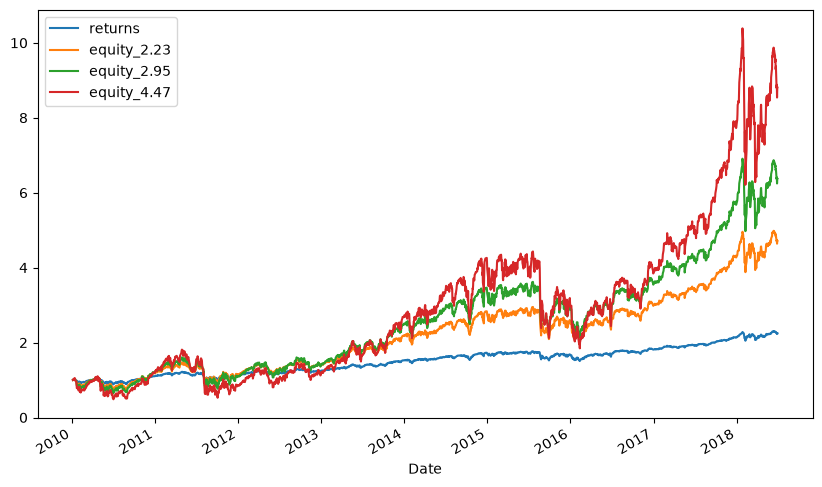

In [35]:
ax = data['returns'].cumsum().apply(np.exp).plot(legend=True, figsize=(10, 6))
data[equs].plot(ax=ax, legend=True)

최적의 켈리 기준 레버리지를 적용하면 자산의 변동성이 크게 증가.

레버리지가 클수록 변동성도 커지기 때문.

따라서 실제로는 켈리 기준보다 적게 사용.

켈리 레버리지를 줄일수록 위험이 줄어드는 것을 볼 수 있음.

## 16.2 머신러닝 기반 매매 전략

과거 데이터와 시장의 방향을 예측하는 머신러닝 방법론을 결합하여 EUR/USD 환율에 대한 알고리즘 트레이딩 전략을 백테스팅.

매수 매도 스프레드를 거래 비용으로 감안.

매매 전략의 위험 특성에 대해 더 심도 있는 분석.

### 16.2.1 벡터화된 백테스팅

5분봉 데이터를 기반으로 백테스팅.

전체 기간에 대해 중간가격 종가를 시각화.

1. API 연결 및 데이터 수집

2. 매수 매도 스프레드 평균 계산 (`spread = (data['askclose'] - data['bidclose']).mean()`)

3. 매수 종가와 매도 종가의 중간가격 계산 (`data['midclose'] = (data['askclose'] + data['bidclose']) / 2`)

4. 평균 스프레드와 평균 중간가격에서 평균 매매 비용 계산 (`ptc = spread / data['midclose'].mean()`)

머신러닝 기반 전략은 이진화된 과거 수익률을 기반으로.

다음날 상승할지 하락할지 여부를 과거의 상승 및 하락 패턴에서 학습한다는 뜻.

입력으로 사용할 특징 데이터는 0 또는 1로, 예측하고자 하는 시장 방향은 +1과 -1로 레이블링.

1. 주어진 날짜만큼 과거 수익률 데이터 생성 (`data[col] = data['returns'].shift(lag)`)

2. 특징값을 이진수로 변환 (`data[cols] = np.where(data[cols] > 0, 1, 0)`)

3. 수익률 데이터를 방향 레이블로 변환 (`data['direction'] = np.where(data['returns'] > 0 , 1, -1)`)

지도 학습 알고리즘 적용

`scikin-learn` 머신러닝 패키지의 분류용 서포트 벡터 머신 알고리즘을 사용.

연속적 학습-검증 분리 방법으로 알고리즘 트레이딩 전략을 학습시키고 검증.

모델의 정확도는 학습 데이터에서 50%를 약간 넘고 검증 데이터에서 조금 더 높음.

금융 관점에서 정확도 지표 대신에 예측에 성공한 매매의 비율인 히트 비율을 사용할 수도 있음.

히트 비율이 50%를 넘기 때문에 켈리 기준에서 보았을 때 랜덤워크 가설보다는 수익 가능성이 더 있다고 할 수 있음.

1. 학습용 데이터를 사용한 표본 내 정확도ㄷ (`accuracy_score(train['direction'], model.predict(train[cols]))`)

2. 검증용 데이터를 사용한 표본 외 정확도 (`accuracy_score(test['direction'], model.predict(test[cols]))`)

히트 비율은 금융거래에서 성공의 한 면만 보여줌.

또 다른 중요 지표는 매매 전략에서의 거래 비용과 중요 매매를 잘 했는지 여부.

지금까지의 벡터화된 백테스팅 방법은 단지 매매 전략을 정성적으로 평가하는 것일 뿐.

평균 매수 매도 스프레드에 의한 일정 비율의 거래 비용을 감안.

거래 비용을 감안했을 때와 감안하지 않았을 때의 알고르짐 트레이딩 전략의 성과를 패시브 벤치마크 투자와 비교.

1. 머신러닝 기반의 알고리즘 트레이딩 전략의 로그 수익률 계산 (`test['strategy'] = test['position'] * test['returns']`)

2. 포지션 방향을 기반으로 매매 전략에서의 매매 횟수 계산 (`sum(test['position'].diff() != 0)`)

3. 매매가 발생할 때마다 그에 비례하는 거래 비용을 그 날의 로그 수익률에서 제외 (`test['strategy_tc'] = np.where(test['position'].diff() != 0, test['strategy'] - ptc, test['strategy'])`)

벡터화된 백테스팅의 한계.

지금까지의 벡터화된 백테스팅은 현실에 가깝게 하는 데 한계가 있음.

매매할 때마다 고정된 거래 비용을 감안하지 않음.

대신 대략적으로 매매 규모에 비례하는 평균적인 거래 비용을 감안할 수는 있음.

하지만 이렇게 하는 것은 일반적으로 정확하지 않음. 

더 높은 정밀도가 필요하면 각각의 분봉에 대해 명시적인 반복을 사용하는 **이벤트 기반의 벡테스팅**을 적용해야함. 

### 16.2.2 최적 레버리지

매매 전략의 로그 수익률이 있으면 평균과 분산을 계산해서 켈리 기준에 따른 최적의 레버리지를 유도할 수 있음.

평균과 분산을 연율화하여 계산함.

같은 값을 사용하기 때문에 연율화로 인해서 최적 레버리지가 바뀌지는 않음.

1. 연율화된 평균 수익률 (`mean = test[['returns', 'strategy_tc']].mean() * len(data) * 12`)

2. 연율화된 분산 (`var = test[['returns', 'strategy_tc']].var() * len(data) * 12`)

3. 연율화된 변동성 (`vol = var ** 0.5`)

4. 켈리 기준에 따른 최적 레버리지 (`mean / var`)

5. 절반 켈리 기준에 따른 최적 레버리지 (`mean / var * 0.5`)

절반 켈리 기준을 사용하면 이 매매 전략의 최적 레버리지는 약 40.

레버리지 비율을 다르게 적용했을 때 거래 비용을 감안한 매매 전략의 성과

1. 여러 가지 레버리지 비율로 전략 스케일링 (`test['lstrategy_tc_{lev}'] = test['strategy_tc'] * lev`)

### 16.2.3 위험 분석

레버리지 비율의 증가는 매매 전략과 관련된 위험을 증가시키므로 더 심도 있는 위험 분석이 필요.

레버리지 비율이 30이라고 ㄱ가정.

**최대손실낙폭**(maximum drawdown)과 **최장손실구간**(longest drawdown period)을 계산.

- 최대손실낙폭: 가장 최근의 최대 수익 시점에서 떨어진 최대의 손실

- 최장손실구간: 가장 최근의 최대 수익 수준까지 되돌아가는데 필요한 시간

레버리지가 30이므로 최초의 자본 수준이 3,333이고 포지션 수준이 100,000이라 가정.

전략 실행 중에 성과가 어떻게 되든 자본을 더 넣거나 빼지 않는다고 가정.

1. 최초 자본금 (`equity = 3333`)

2. 로그 수익률 시계열 (`risk = pd.DataFrame['lstrategy_tc_30']`)

3. 최초 자본금을 곱해서 스케일링 (`risk['equity'] = risk['lstrategy_tc_30].cumsum().apply(np.exp) * equity`)

4. 누적 최댓값 (`risk['cummax'] = risk['equity'].cummmax()`)

5. 손실낙폭 (`risk['drawdown'] = risk['cummax'] - risk['equity']`)

6. 최대손실낙폭 (`risk['drawdown'].max()`)

7. 발생 시점 (`t_max = risk['drawdown'].idxmax()`)

기술적으로 새로운 최고점에서 최대손실낙폭은 0.

손실구간은 두 개의 최댓값 사이의 기간.

1. 손실낙폭이 0이 되는 지점 찾기 (`temp = risk['drawdown'][risk['drawdown'] == 0]`)

2. 최대 지점 사이의 시간 계산 (`periods = (temp.index[1:].to_pydatetime() - temp.index[:-1].to_pydatetime())`)

3. 최장손실구간 계산(초 단위) (`t_per = periods.max()`)

4. 시간 단위 변환 (`t_per.seconds / 60 / 60`)

또 하나의 중요한 위험 지표는 VaR(value-at-risk).

VaR값은 특정 기간 내에 특정 확률로 발생할 수 있는 최대 손실을 금액으로 나타낸 것.

다양한 신뢰수준에 대한 레버리지 매매 전략의 자본금 수익률에 기반하여 VaR값을 유도. 

기간은 5분봉의 길이로 고정.

1. 사용할 신뢰수준 (`percs = np.array([0.01, 0.1, 1., 2.5, 5.0, 10.0])`)

2. 주어진 신뢰수준에 따른 VaR값 계산 (`VaR = scs.scoreatpercentile(equity * risk['returns'], percs)`)

3. 신뢰수준을 신뢰구간으로 변환하고 VaR값을 양수로 변환하여 출력 (`print(f'{100 - percs:16.2f} {Var:16.3f}')`)

원래의 DataFrame 객체를 리샘플링하여 한 시간 단위의 VaR값을 계산.

실질적으로 각 신뢰구간에 대한 VaR값은 증가.

1. 5분봉에서 1시간 간격으로 리샘플링 (`hourly = risk.resample('1H', label='right').last()`)

2. 리샘플링된 데이터의 VaR값 재계산 (`VaR = scs.scoreatpercentile(equity * hourly['returns'], percs)`)

### 16.2.4 모형 객체 보존

백테스팅, 레버리지 분석, 위험 분석 결과에서 알고리즘 트레이딩 전략이 통과되었으면 나중에 사용하기 위해 이 매매 전략 객체를 보존해야 함.

보존된 객체는 전략 내용을 내포하고 있음.

`pickle.dump(model, open('algorithm.pkl', 'wb'))`

## 16.3 온라인 알고리즘

지금까지 테스트한 트레이딩 알고리즘은 오프라인 알고리즘. 

문제를 풀기 위해 필요한 데이터가 완벽하게 주어져 있다고 가정하고 만든 것. 

여기서 주어진 문제는 이진화된 특징값과 레이블링된 시장 방향을 사용하여 서포트 벡터 머신 기반의 알고리즘을 학습시키는 것. 

실제로 이 트레이딩 알고리즘을 금융 시장에 배포할 때는 데이터가 조각조각 도착하게 되고 이 값을 기반으로 시장 방향을 예측해야 함. 

보존했던 모형 객체를 사용하여 실시간 환경에 적용. 

오프라인 트레이딩 알고리즘 코드를 온라인 트레이딩 알고리즘으로 바꿀 때는 다음과 같은 점에 주의.

- **틱 데이터**: 틱 데이터는 실시간으로 도착하고 실시간으로 처리되어야 함. 

- **리샘플링**: 틱 데이터는 트레이딩 알고리즘에서 주어진 봉 간격에 맞게 리샘플링해야 함. 

- **예측**: 트레이딩 알고리즘은 주어진 시간 이후의 시장 방향을 예측해야 함. 

- **주문**: 현재의 포지션 정보와 알고리즘에 의한 시장 예측이 주어지면 포지션 정보에 맞게 주문이 나가야 함. 

시장 데이터 스트림 수신을 신청하고 데이터를 처리할 콜백 함수를 넘기는 것.

보존했던 트레이딩 알고리즘을 다시 로드.

이 알고리즘이 우리가 사용할 트레이딩 로직.

트레이딩 알고리즘이 매매하는 동안 포지션을 출력하는 보조 함수를 정의하면 유용.

1. 출력할 DataFrame 열 (`sel = ['tradeId', 'amountK', 'currency', 'grossPL', 'isBuy']`)

2. 실행될 때까지 대기 (`time.sleep(1.5)`)

3. 현재 포지션 출력 (`print(api.get_open_positions()[sel])`)

온라인 알고리즘을 정의하고 시작하기 전에 몇 가지 매개변수 설정.

1. 매매할 상품 심볼 (`symbol = 'EUR/USD'`)

2. 리샘플링할 봉 간격. 테스트를 위해 실제보다 짧게 설정. (`bar = '15s'`)

3. 매매 수량 (`amount = 100`)

4. 초기 포지션 (`position = 0`)

5. 첫 번째 예측에 사용될 리샘플링된 봉의 최소 개수 (`min_bars = lags + 1`)

6. 리샘플링된 데이터에 사용할 빈 DataFrame 객체 (`df = pd.DataFrame()`)

트레이딩을 실시간으로 바꾸는 `automated_strategy()` 콜백 함수


    def automated_strategy(data, dataframe):
        global min_bars, position, df

        ldf = len(dataframe) # 틱 데이터가 있는 DataFrame 객체의 길이
        df = dataframe.resample(bar, label='right').last().ffill() # 정의된 봉 길이에 맞게 틱 데이터 리샘플링

        if ldf % 20 == 0:
            print(f'{len(dataframe):3d}', end=',')
        
        if len(df) > min_bars:
            min_bars = len(df)

            df['Mid'] = df[['Bid', 'Ask']].mean(axis=1)
            df['Returns'] = np.log(df['Mid]).diff()
            df['Directions'] = np.where(df['Returns'] > 0, 1, -1)

            features = df['Direction'].iloc[-(lags + 1):-1] # 모든 과거 데이터 중 필요한 부분 선택
            features = features.values.reshape(1, -1) # 예측 모형에 맞는 형태로 변환

            signal = algorithm.predict(features)[0] # 예측값 출력(+1 또는 -1)

            if position in [0, -1] and signal == 1: # 매수 포지션 조건
                api.create_market_buy_order(symbol, amount - position * amount)
                position = 1
                print_positions('LONG')
            
            elif position in [0, 1] and signal == -1: # 매도 포지션 조건
                api.create_market_sell_order(symbol, amount + position * amount)
                position = -1
                print_positions('SHORT')
        
        if len(dataframe) > 350: # 매매를 중지하거나 완료하는 조건
            api.unsubscribe_market_data('EUR/USD')
            api.close_all()

## 16.4 기반구조와 배포

실제 자금을 사용하여 자동화된 알고리즘 트레이딩 전략을 실행할 때는 적절한 기반구조가 필요.

기반구조는 다음과 같은 조건을 갖춰야 함.

- **신뢰성**: 99.9% 이상의 고가용성(high availability)을 가지고 있어야 하며 (자동 백업, 드라이브 및 웹 연결의 다중화 등) 여러 가지 신뢰성 기준을 만족해야 함. 

- **성능**: 처리하는 데이터의 양과 알고리즘이 사용하는 계산햘에 따라서 기반구조는 충분한 CPU 코어, 메모리, 디스크 용량을 가지고 있어야. 네트워크 속도도 충분히 빨라야 함. 

- **보안**: 운영체제와 애플리케이션은 강력한 패스워드와 SSL 암호화로 보호되어야 함. 하드웨어 또한 화재나 수해 혹은 인가되지 않은 물리적 접근으로부터 보호되어야 함.

전문적 데이터 센터나 클라우드 서비스.

개인 컴퓨터에서 개발 및 테스트할 수도 있지만 실제로 자금을 사용하는 전략에서는 적절하지 않음.

인터넷 연결이 끊어져서 예기치 못한 데이터 손실이 발생할 수도 있음.

실시간 틱 데이터의 누락으로 인해 의도치 않은 매매가 발생할 수도 있음.

## 16.5 로깅과 모니터링

로깅은 나중에 검사할 수 있도록 각종 정보와 이벤트를 디스크에 저장해놓는 것.

금융 측면에 초점을 맞춰 중요한 데이터를 나중에 분석하거나 조사하는 데 사용.

소켓 커뮤니케이션을 사용한 실시간 모니터링도 중요.

클라우드에서 배포가 이루어지더라도 중요한 금융 정보는 소켓을 통해 지속적으로 개인용 컴퓨터에서 처리되고 있어야 함.

automated_strategy.py
```
#
# Automated ML-Based Trading Strategy for FXCM
# Online Algorithm, Logging, Monitoring
#
# Python for Finance, 2nd ed.
# (c) Dr. Yves J. Hilpisch
#
import zmq
import time
import pickle
import fxcmpy
import numpy as np
import pandas as pd
import datetime as dt

sel = ['tradeId', 'amountK', 'currency',
       'grossPL', 'isBuy']

log_file = 'automated_strategy.log'

# loads the persisted algorithm object
algorithm = pickle.load(open('algorithm.pkl', 'rb'))

# sets up the socket communication via ZeroMQ (here: "publisher")
context = zmq.Context()
socket = context.socket(zmq.PUB)

# this binds the socket communication to all IP addresses of the machine
socket.bind('tcp://0.0.0.0:5555')


def logger_monitor(message, time=True, sep=True):
    ''' Custom logger and monitor function.
    '''
    with open(log_file, 'a') as f:
        t = str(dt.datetime.now())
        msg = ''
        if time:
            msg += '\n' + t + '\n'
        if sep:
            msg += 66 * '=' + '\n'
        msg += message + '\n\n'
        # sends the message via the socket
        socket.send_string(msg)
        # writes the message to the log file
        f.write(msg)


def report_positions(pos):
    ''' Prints, logs and sends position data.
    '''
    out = '\n\n' + 50 * '=' + '\n'
    out += 'Going {}.\n'.format(pos) + '\n'
    time.sleep(2)  # waits for the order to be executed
    out += str(api.get_open_positions()[sel]) + '\n'
    out += 50 * '=' + '\n'
    logger_monitor(out)
    print(out)


def automated_strategy(data, dataframe):
    ''' Callback function embodying the trading logic.
    '''
    global min_bars, position, df
    # resampling of the tick data
    df = dataframe.resample(bar, label='right').last().ffill()

    if len(df) > min_bars:
        min_bars = len(df)
        logger_monitor('NUMBER OF BARS: ' + str(min_bars))
        # data processing and feature preparation
        df['Mid'] = df[['Bid', 'Ask']].mean(axis=1)
        df['Returns'] = np.log(df['Mid'] / df['Mid'].shift(1))
        df['Direction'] = np.where(df['Returns'] > 0, 1, -1)
        # picks relevant points
        features = df['Direction'].iloc[-(lags + 1):-1]
        # necessary reshaping
        features = features.values.reshape(1, -1)
        # generates the signal (+1 or -1)
        signal = algorithm.predict(features)[0]

        # logs and sends major financial information
        logger_monitor('MOST RECENT DATA\n' +
                       str(df[['Mid', 'Returns', 'Direction']].tail()),
                       False)
        logger_monitor('features: ' + str(features) + '\n' +
                       'position: ' + str(position) + '\n' +
                       'signal:   ' + str(signal), False)

        # trading logic
        if position in [0, -1] and signal == 1:  # going long?
            api.create_market_buy_order(
                symbol, size - position * size)  # places a buy order
            position = 1  # changes position to long
            report_positions('LONG')

        elif position in [0, 1] and signal == -1:  # going short?
            api.create_market_sell_order(
                symbol, size + position * size)  # places a sell order
            position = -1  # changes position to short
            report_positions('SHORT')
        else:  # no trade
            logger_monitor('no trade placed')

        logger_monitor('****END OF CYCLE***\n\n', False, False)

    if len(dataframe) > 350:  # stopping condition
        api.unsubscribe_market_data('EUR/USD')  # unsubscribes from data stream
        report_positions('CLOSE OUT')
        api.close_all()  # closes all open positions
        logger_monitor('***CLOSING OUT ALL POSITIONS***')


if __name__ == '__main__':
    symbol = 'EUR/USD'  # symbol to be traded
    bar = '15s'  # bar length; adjust for testing and deployment
    size = 100  # position size in thousand currency units
    position = 0  # initial position
    lags = 5  # number of lags for features data
    min_bars = lags + 1  # minimum length for resampled DataFrame
    df = pd.DataFrame()
    # adjust configuration file location
    api = fxcmpy.fxcmpy(config_file='../fxcm.cfg')
    # the main asynchronous loop using the callback function
    api.subscribe_market_data(symbol, (automated_strategy,))
```

strategy_monitoring.py
```
#
# Automated ML-Based Trading Strategy for FXCM
# Strategy Monitoring via Socket Communication
#
# Python for Finance, 2nd ed.
# (c) Dr. Yves J. Hilpisch
#
import zmq

# sets up the socket communication via ZeroMQ (here: "subscriber")
context = zmq.Context()
socket = context.socket(zmq.SUB)

# adjust the IP address to reflect the remote location if necessary
socket.connect('tcp://206.189.51.42:5555')

# configures the socket to retrieve every message
socket.setsockopt_string(zmq.SUBSCRIBE, '')

while True:
    msg = socket.recv_string()
    print(msg)
```